In [7]:
#MultiRegression0820

In [8]:
import pandas as pd
import numpy as np
import warnings as wr
wr.filterwarnings(action='ignore')
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
#이미지를 읽어 들이기 위한 라이브러리 추가
import matplotlib.image as mpimg
import matplotlib as mpl
from PIL import Image
import seaborn as sns
import os
font_list = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
#한글처리 -> 코랩에서는 별도로 다시 강의 
plt.rcParams['font.family'] ="NanumGothic"
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
#MLModel
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error
# 교차검증은 한번에 test데이터를 가지고 score()하는것이 아니라
# 마치 모의고사를 여러번 보고 평균을 구하는 방식이다.
# cross_val_score 함수를 사용하면 끝이다. ㅎㅎ
from sklearn.model_selection import train_test_split ,cross_val_score #데이터 분할 모듈

<p>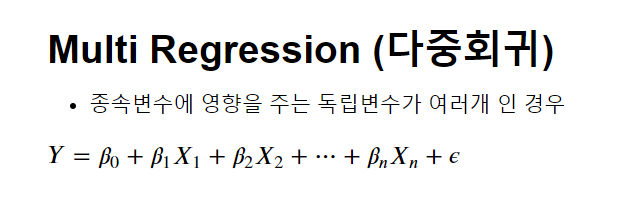</p>

In [9]:
os.listdir('dataset')

['Advertising.csv',
 'auto-mpg.csv',
 'challenger.csv',
 'five.png',
 'linear.csv',
 'manhattan.csv',
 'rabbit.jpg']

In [10]:
#Advertising.csv 광고료를 지불했을 때 판매량 분석 데이터 
df = pd.read_csv('dataset/Advertising.csv', index_col=0)
df.head(2)

,FB,TV,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   FB         200 non-null    float64
 1   TV         200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [12]:
df.isnull().sum()

FB           0
TV           0
Newspaper    0
Sales        0
dtype: int64

In [14]:
df.describe()

,FB,TV,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


In [15]:
# step1) 독립변수 , 종속변수 
X = df[['FB','TV','Newspaper']].values
Y = df['Sales'].values

In [16]:
#(data - mean) / std
def standardize(data):
    #1) 데이터에서 각행의 평균을 구한다. 행을 따라 내려가면서 계산
    mean = np.mean(data,axis=0)
    #2) 표준편차
    std = np.std(data,axis=0)
    return (data - mean) / std

In [17]:
# step2) 데이터 분할 하기 0.3 , rs = 42
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

In [18]:
# step3) 분할한 데이터를 각각 스케일 처리 하기 
X_train_std = standardize(X_train)
Y_train_std = standardize(Y_train)
X_test_std =  standardize(X_test)
Y_test_std = standardize(Y_test)

In [19]:
X_train_std.shape

(140, 3)

In [20]:
#독립변수의 갯수만큼 제로벡터를 생성한다.
initial_betas = np.zeros(X_train_std.shape[1])
initial_betas

array([0., 0., 0.])

In [21]:
# step 4) 학습을 위한 함수들을 정의 , 오차 , 경사하강법 함수 -> 가중치들 와 편향 
# W1*X1 + W2*X2 + .... W3*Xn + b
def MSE(X,y,betas):
    N = len(y)
    y_predicted = np.dot(X,betas)
    # 실제값 - 예측값
    squared_loss = (y - y_predicted) ** 2
    mse = np.sum(squared_loss) / N
    return mse

In [22]:
comm="""
# 손실 함수의 미분을 계산하기 위한 함수
def gradients(x, y, beta_0, beta_1):
    n = len(x)
    x = np.array(x)
    y = np.array(y)
    y_predicted = beta_0 * x + beta_1
    d_beta_0 = -2 * np.sum(x * (y - y_predicted)) #기울기에 대한 편미분
    d_beta_1 = -2 * np.sum(y - y_predicted) # 절편에 대한 편미분
    #미분값을 총합 n으로 나눠서 평균을 구해서 반환 -> 평균 기울기 
    return d_beta_0 / n , d_beta_1 / n 
"""
def gradients(X, y, betas):
    y_predicted = np.dot(X, betas)
    errors = y - y_predicted
    d_betas = -2 * np.dot(X.T, errors) / len(y)
    return d_betas

In [23]:
'''
def gradient_descent(x, y, beta_0, beta_1,learning_rate,epochs):
    for i in range(epochs):
        #경사하강법을 통해서 갱신된 기울기,절편을 반환 
        d_beta_0, d_beta_1 = gradients(x,y,beta_0,beta_1)
        #학습률 만큼 적용 하는데 .... 
        # *****************************************************************
        #학습률이 너무 크거나 데이터 스케일이 크면 기울기 업데이트가 너무커져서 
        #inf 즉 무한대가된다.  
        #inf 연산하면 결국 nan이 된다. 
        # *****************************************************************
        beta_0 -= learning_rate * d_beta_0
        print(f"beta_0 : {beta_0}")
        beta_1 -= learning_rate * d_beta_1
        if i % 1000 == 0:
            print(f"Epoch : {i} => Loss => {MSE(x,y,beta_0,beta_1)}")
    return beta_0, beta_1
'''
def gradient_descent(X, y, betas, learning_rate, epochs):
    loss_history = []
    betas_history = []
    for i in range(epochs):
        d_betas = gradients(X,y,betas)
        betas -= learning_rate * d_betas
        current_loss = MSE(X,y,betas)
        loss_history.append(current_loss)
        betas_history.append(betas)
        if i % 100 == 0:
            print(f"Epoch : {i} => Loss => {current_loss}")
    return betas_history, loss_history

In [24]:
epochs = 2500
learning_rate = 0.001
initial_betas = np.zeros(X_train_std.shape[1])
betas_history, loss_history = gradient_descent(X_train_std,Y_train_std,initial_betas,\
                                              learning_rate,epochs)

Epoch : 0 => Loss => 0.9959110590222678
Epoch : 100 => Loss => 0.6701737884598001
Epoch : 200 => Loss => 0.4652564546971556
Epoch : 300 => Loss => 0.335349954287748
Epoch : 400 => Loss => 0.25233624572608987
Epoch : 500 => Loss => 0.19885069489262397
Epoch : 600 => Loss => 0.16409984975783298
Epoch : 700 => Loss => 0.1413287520098447
Epoch : 800 => Loss => 0.12627956490670325
Epoch : 900 => Loss => 0.1162484799454571
Epoch : 1000 => Loss => 0.10950536981647699
Epoch : 1100 => Loss => 0.10493448436295646
Epoch : 1200 => Loss => 0.10181056814300142
Epoch : 1300 => Loss => 0.0996584214198193
Epoch : 1400 => Loss => 0.0981641901462854
Epoch : 1500 => Loss => 0.09711892929028987
Epoch : 1600 => Loss => 0.09638243527145325
Epoch : 1700 => Loss => 0.09585989579071329
Epoch : 1800 => Loss => 0.09548670193616532
Epoch : 1900 => Loss => 0.09521849533751488
Epoch : 2000 => Loss => 0.09502459720523866
Epoch : 2100 => Loss => 0.09488363795195075
Epoch : 2200 => Loss => 0.09478062910455799
Epoch : 2

In [25]:
# loss_history에서 가장 낮은 손실을 갖는 인덱스 찾기 ?
min_loss_index = np.argmin(loss_history)
print(f"argmin => {min_loss_index}")
#betas_history에서 min_loss_index 구한 것으로 최종적으로 가중치들 즉 가장 낮은 오차의 모델의 가중치들을 선택 
final_betas = betas_history[min_loss_index]
#final_betas
test_loss = MSE(X_test_std,Y_test_std,final_betas)
print(f"Test Loss : {test_loss}")

argmin => 2499
Test Loss : 0.13643160863573986


In [26]:
# 예측 
df.columns

Index(['FB', 'TV', 'Newspaper', 'Sales'], dtype='str')

In [27]:
new_data = np.array([230.1, 58.4, 46.8])
# X_train과 Y_train의 평균과 표준편차 계산 => 새로운 값에 대한 표준화 처리를 위해서
mean_X_train = np.mean(X_train,axis=0)
std_X_train = np.std(X_train,axis=0)
mean_Y_train = np.mean(Y_train)
std_Y_train = np.std(Y_train)
new_data_std = (new_data - mean_X_train) / std_X_train

#예측을 구현 
prediected_std = np.dot(new_data_std, final_betas)
prediected_std

#원래대로 복원 해보기
prediected = prediected_std * std_Y_train + mean_Y_train
print(f"예측값 [Sales] => {prediected}")

예측값 [Sales] => 24.718571506319343


<h2 id="%EC%82%AC%EC%9D%B4%ED%82%B7%EB%9F%B0%EC%9D%84-%EC%82%AC%EC%9A%A9%ED%95%B4%EC%84%9C-StandardScaler-%EC%82%AC%EC%9A%A9%ED%95%B4%EB%B3%B4%EA%B8%B0">사이킷런을 사용해서 StandardScaler 사용해보기¶</h2>

In [28]:
# step1) 독립변수 , 종속변수 
X = df[['FB','TV','Newspaper']].values
Y = df['Sales'].values
# step2) 데이터 분할 하기 0.3 , rs = 42
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)
print(X_train.shape, Y_train.shape)
print(Y_train.reshape(-1,1).shape)

(140, 3) (140,)
(140, 1)


In [36]:
# step3) 표준화 적용 - 훈련용은 학습을 시킬때, 테스트는 예측및 검증할때
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

In [37]:
#Train만 fit 해라~~ Test는 감춰났다가 잘 맞췄나 못맞췃냐 확인용 
X_train_std = scaler_X.fit_transform(X_train)
X_test_std = scaler_X.transform(X_test)

In [38]:
#원래 차원으로 복원하기 위해서 .flatten()
Y_train_std = scaler_Y.fit_transform(Y_train.reshape(-1,1)).flatten()
Y_test_std  = scaler_Y.transform(Y_test.reshape(-1,1)).flatten()

In [41]:
# step4) 모델을 생성 하고 학습 - train 
model = LinearRegression()
model.fit(X_train_std,Y_train_std)
print("모델 학습 완료!")
print(model.coef_)
print(model.intercept_)

모델 학습 완료!
[0.71903789 0.56733974 0.02771011]
-6.357149004562006e-16


In [43]:
# step5) 예측 -> 오차
Y_pred = model.predict(X_test_std)
mse = mean_squared_error(Y_test_std,Y_pred)
score = model.score(X_test_std,Y_test_std)
print(f"Test MSE : {mse}")
print(f"Test Score : {score}")

Test MSE : 0.14468954757266791
Test Score : 0.8609466508230369


In [44]:
# step6)
new_data = np.array([[230.1, 58.4, 46.8]])
new_data_std = scaler_X.transform(new_data)
pred = model.predict(new_data_std)
pred
predicted_sales = scaler_Y.inverse_transform(pred.reshape(-1,1))
print(f"예측값 : {predicted_sales}")

예측값 : [[24.80747822]]


In [45]:
#https://ko.wikipedia.org/wiki/맨해튼_거리

<h2 id="Norm-(%EB%85%B8%EB%A6%84)">Norm (노름)¶</h2>
벡터의 크기또는 길이를 측정하는 방법 이다.

<h3 id="L1-Norm(%EB%A7%A8%ED%95%B4%ED%8A%BC-%EB%85%B8%EB%A6%84,-%ED%83%9D%EC%8B%9C-%EB%85%B8%EB%A6%84)">L1 Norm(맨해튼 노름, 택시 노름)¶</h3>
L1 노름은 벡터의 각 요소의 절대값의 합으로 계산
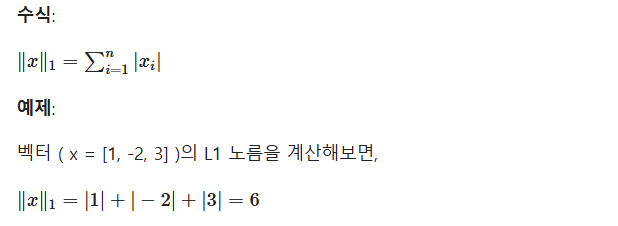

<hr />
<h2 id="L2-Norm-(%EC%9C%A0%ED%81%B4%EB%A6%AC%EB%93%9C-%EB%85%B8%EB%A6%84)">L2 Norm (유클리드 노름)¶</h2><h3 id="L2-%EB%85%B8%EB%A6%84%EC%9D%80-%EB%B2%A1%ED%84%B0-%EC%9A%94%EC%86%8C%EC%9D%98-%EC%A0%9C%EA%B3%B1%ED%95%A9%EC%9D%98-%EC%A0%9C%EA%B3%B1%EA%B7%BC%EC%9C%BC%EB%A1%9C-%EA%B3%84%EC%82%B0">L2 노름은 벡터 요소의 제곱합의 제곱근으로 계산¶</h3><p>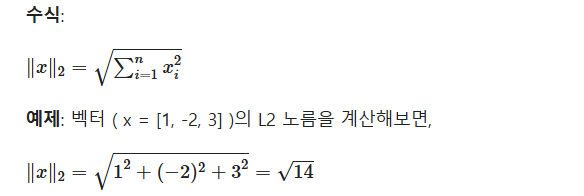</p>

In [46]:
# 규제 실습
#! pip install mglearn

In [47]:
#<규제 실습>
# 회귀 분석용 실제 데이터셋으로는 보스턴 주택가격 데이터 셋
# 범죄율, 찰스강 인접도, 고속도로 접근성 등의 정보를 이용해 1970년대 보스턴 주변의
# 주택 평균 가격을 예측하는 것.
# 데이터 포인트 506개와 특성 13개
# 코랩에서 사이킷런 버전 관계로 import 안됨

In [52]:
#!pip install mglearn

In [53]:
from mglearn.datasets import load_boston, load_extended_boston

In [54]:
boston = load_boston()
print(boston.data.shape)
boston.target.shape

(506, 13)


(506,)

In [55]:
comm="""
Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
        - NOX      nitric oxides concentration (parts per 10 million)
        - RM       average number of rooms per dwelling
        - AGE      proportion of owner-occupied units built prior to 1940
        - DIS      weighted distances to five Boston employment centres
        - RAD      index of accessibility to radial highways
        - TAX      full-value property-tax rate per $10,000
        - PTRATIO  pupil-teacher ratio by town
        - B        1000(Bk - 0.63)^2 where Bk is the proportion of black people by town
        - LSTAT    % lower status of the population
        - MEDV     Median value of owner-occupied homes in $1000's

CRIM: 인구 1인당 범죄율 (마을별)

ZN: 25,000 평방피트(약 695평) 이상의 주거용 토지 비율 (마을별)

INDUS: 비소매(non-retail) 상업용 토지 비율 (마을별)

CHAS: 찰스강 인접 여부 더미 변수

1 → 해당 구역이 찰스강과 맞닿아 있음

0 → 맞닿아 있지 않음

NOX: 일산화질소 농도 (10백만분의 1 단위)

RM: 주택 1가구당 평균 방 개수

AGE: 1940년 이전에 지어진 주택 비율 (자기 소유 주택 기준)

DIS: 보스턴 5대 주요 고용지구까지의 가중 거리

RAD: 방사형 고속도로 접근성 지수

TAX: 재산세율 (10,000달러당)

PTRATIO: 학급당 학생 대비 교사 비율 (마을별)

B: 흑인 인구 비율 지수 → 계산식:
LSTAT: 저소득층 인구 비율 (%)

MEDV: 자기 소유 주택의 중앙값 가격 (단위: 1,000달러)
"""

In [56]:
# 파생 파라미터가 적용된 데이터 셋 load_extended_boston()
extended_boston = load_extended_boston()

In [57]:
type(extended_boston)
X , y = extended_boston
print(f"특성 : {X.shape}")
X_train,X_test,y_train,y_test= train_test_split(X,y,random_state=0)
lr = LinearRegression().fit(X_train,y_train)
print(f"훈련 점수 :{lr.score(X_train,y_train)}")
print(f"테스트 점수 :{lr.score(X_test,y_test)}")

특성 : (506, 104)
훈련 점수 :0.9520519609032727
테스트 점수 :0.6074721959666014


In [58]:
# 복잡도를 제어할 수 있는 모델을 사용해야 한다.
# 기본 선형회귀 방식 대신에 L1,L2규제를 사용하는
# 릿지(L2,유클리디안) 회귀, 라쏘(L1,맨허튼)회귀 를 사용하면서 각각 비교
# (리지(L2,유클리디안) => 가장 안정적 머신)
# Lasso : |wi| => 특성이 0 이 되는 애들이 생기고, 이렇게 하면 특성 교통정리가 되어 버린다. 
# (특성 선택이 자동으로 적용)
# 확장된 보스턴 주택가격 데이터셋에
# 라쏘(Lasso,L1[맨하턴,택시거리],절대값의합,0이되는것 때문에 특성이 사라짐)를 적용

<p>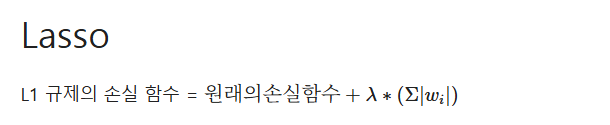</p>

In [59]:
from sklearn.linear_model import Lasso, Ridge

In [60]:
#라쏘(Lasso,L1[맨하턴,택시거리],절대값의합,0이되는것 때문에 특성이 사라짐)를 적용
# alpha=1은 기본값
#과소적합을 발생 - 
# 훈련세트 점수와 테스트 세트 점수 둘다 이렇게 적게 나와서 결과가 형편없는 것을 말한다.
lasso =  Lasso(alpha=1).fit(X_train,y_train)
print(f"훈련 점수 :{lasso.score(X_train,y_train)}")
print(f"테스트 점수 :{lasso.score(X_test,y_test)}")
print(f"x 하나당 w[가중치,기울기]의 갯수 :{lasso.coef_.shape}")
#0이 아닌 애들만 추려내보자.
print(f'추출한 특성의 갯수 : {np.sum(lasso.coef_ != 0)}')

훈련 점수 :0.29323768991114607
테스트 점수 :0.20937503255272294
x 하나당 w[가중치,기울기]의 갯수 :(104,)
추출한 특성의 갯수 : 4


In [61]:
#과소적합을 줄이기 위해서 alpha을 줄여가면서 체크
# max_iter 경사하강법에서 반복횟수를 적용하겠다는 속성 
# 줄인 alpha을 가지고 가장 낮은 오차를 찾아간는 반복값 
lasso001  =  Lasso(alpha=0.01,max_iter=100000).fit(X_train,y_train)
print(f"훈련 점수 :{lasso001.score(X_train,y_train)}")
print(f"테스트 점수 :{lasso001.score(X_test,y_test)}")
print(f"x 하나당 w[가중치,기울기]의 갯수 :{lasso001.coef_.shape}")
#0이 아닌 애들만 추려내보자.
print(f'추출한 특성의 갯수 : {np.sum(lasso001.coef_ != 0)}')

훈련 점수 :0.8962226511086498
테스트 점수 :0.7656571174549981
x 하나당 w[가중치,기울기]의 갯수 :(104,)
추출한 특성의 갯수 : 33


In [62]:
# LinearRegression의 결과
# 훈련 세트 점수: 0.95
# 테스트 세트 점수: 0.61
# alpha를 너무 낮추면 규제의 효과가 없어져 <과대적합>이 되므로 
# LinearRegression의 결과와 비슷해짐
lasso0001 = Lasso(alpha=0.0001,max_iter=100000).fit(X_train,y_train)
print(f"훈련 점수 :{lasso0001.score(X_train,y_train)}")
print(f"테스트 점수 :{lasso0001.score(X_test,y_test)}")
print(f"x 하나당 w[가중치,기울기]의 갯수 :{lasso0001.coef_.shape}")
print(f"정리가 된 이후의 사용된 특성의 갯수 : {np.sum(lasso0001.coef_ != 0)}")

훈련 점수 :0.9507158754515461
테스트 점수 :0.6437467421272836
x 하나당 w[가중치,기울기]의 갯수 :(104,)
정리가 된 이후의 사용된 특성의 갯수 : 96


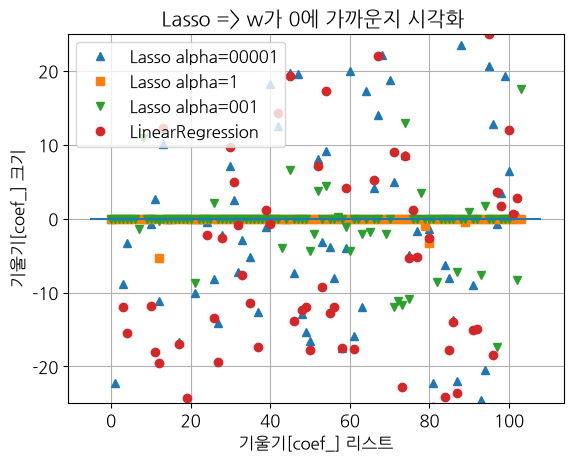

In [63]:
# 0 에 가까운지를 하나씩 시각화 해보기 
plt.plot(lasso0001.coef_,'^',label='Lasso alpha=00001')
plt.plot(lasso.coef_, 's', label="Lasso alpha=1")
plt.plot(lasso001.coef_, 'v', label="Lasso alpha=001")
plt.plot(lr.coef_,'o',label="LinearRegression")
plt.xlabel('기울기[coef_] 리스트')
plt.ylabel('기울기[coef_] 크기')
xlims = plt.xlim() #x축의 시작,끝
plt.hlines(0,xlims[0],xlims[1]) # 직선하나를 좌표 0에 
plt.title('Lasso => w가 0에 가까운지 시각화 ')
plt.ylim(-25, 25)
plt.legend()
plt.grid(True)
plt.show()

<h2 id="%EB%A6%BF%EC%A7%80(Ridge)---L2-,-%EC%9C%A0%ED%81%B4%EB%A6%AC%EB%94%94%EC%95%88-(%EC%A7%81%EC%84%A0)">릿지(Ridge) - L2 , 유클리디안 (직선)¶</h2>
릿지 회귀 분석 ( 가중치 - 파라미터 연관, 가중치의 값을 조정 기울기를 최소화 )
가중치(W) 기울기를 좀 더 작게 만들어 주기 위한 알고리즘이다.
가중치를 0으로는 만들지 않는다.
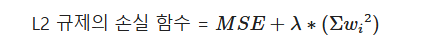

In [64]:
# alpha값을 생략을 해도 기본값은 1.0이다.
ridge = Ridge().fit(X_train,y_train)
print(f"훈련 점수 :{ridge.score(X_train,y_train)}")
print(f"테스트 점수 :{ridge.score(X_test,y_test)}")
print(f"x 하나당 w[가중치,기울기]의 갯수 :{ridge.coef_.shape}")
print(f"정리가 된 이후의 사용된 특성의 갯수 : {np.sum(ridge.coef_ != 0)}")
# alpha을 기본값일때 -> 
# LinearRegression보다 점수가 낮지만, 테스트 세트에 대한 점수는 더 높다는 것을 알수 있다.

훈련 점수 :0.8857966585170941
테스트 점수 :0.7527683481744755
x 하나당 w[가중치,기울기]의 갯수 :(104,)
정리가 된 이후의 사용된 특성의 갯수 : 104


In [65]:
lr.coef_[:3] , ridge.coef_[:3]

(array([-412.7109467 ,  -52.24320682, -131.89881469]),
 array([-1.41368408, -1.55661895, -1.46543409]))

In [66]:
# alpha의 default값으로 10
ridge10 = Ridge(alpha=10,max_iter=100000).fit(X_train,y_train)
print(f"훈련 점수 :{ridge10.score(X_train,y_train)}")
print(f"테스트 점수 :{ridge10.score(X_test,y_test)}")
print(f"x 하나당 w[가중치,기울기]의 갯수 :{ridge10.coef_.shape}")
print(f"정리가 된 이후의 사용된 특성의 갯수 : {np.sum(ridge10.coef_ != 0)}")

훈련 점수 :0.7882787115369614
테스트 점수 :0.635941148917731
x 하나당 w[가중치,기울기]의 갯수 :(104,)
정리가 된 이후의 사용된 특성의 갯수 : 104


In [67]:
lr.coef_[:3] , ridge.coef_[:3] , ridge10.coef_[:3]

(array([-412.7109467 ,  -52.24320682, -131.89881469]),
 array([-1.41368408, -1.55661895, -1.46543409]),
 array([-0.81160963,  0.6476089 , -0.80978323]))

In [68]:
# alpha의 default값으로 0.01
ridge001  = Ridge(alpha=0.01,max_iter=100000).fit(X_train,y_train)
print(f"훈련 점수 :{ridge001 .score(X_train,y_train)}")
print(f"테스트 점수 :{ridge001 .score(X_test,y_test)}")
print(f"x 하나당 w[가중치,기울기]의 갯수 :{ridge001 .coef_.shape}")
print(f"정리가 된 이후의 사용된 특성의 갯수 : {np.sum(ridge001 .coef_ != 0)}")

훈련 점수 :0.9444599240824939
테스트 점수 :0.7022485939223795
x 하나당 w[가중치,기울기]의 갯수 :(104,)
정리가 된 이후의 사용된 특성의 갯수 : 104


In [69]:
# alpha값을 0에 가까이하면 자연스럽게 가중치 값은 0으로 근사하며
# LinearRegression의 결과와 거의 같아진다.
# 이 데이터에서는 0.1로 설정할 때 테스트에서 괜찮은 성능임을 확인
ridge01 = Ridge(alpha=0.1,max_iter=100000).fit(X_train,y_train)
print("훈련 세트 점수: {:.2f}".format(ridge01.score(X_train, y_train)))
print("테스트 세트 점수: {:.2f}".format(ridge01.score(X_test, y_test)))
print(f"사용한 특성값에 붙은 x당 w의 갯수 {ridge01.coef_.shape}")
print("사용한 특성의 개수:", np.sum(ridge01.coef_ !=0))

훈련 세트 점수: 0.93
테스트 세트 점수: 0.77
사용한 특성값에 붙은 x당 w의 갯수 (104,)
사용한 특성의 개수: 104


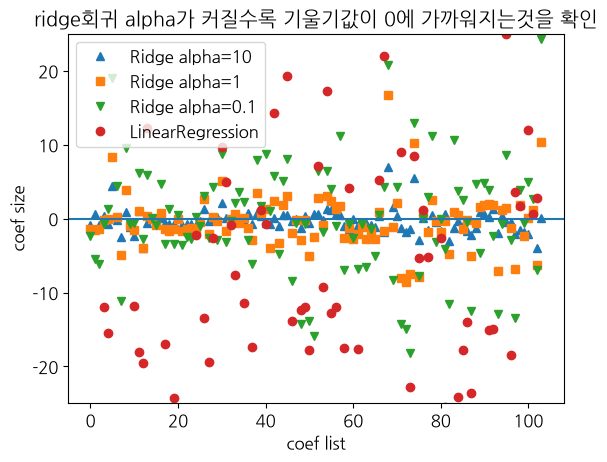

In [70]:
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10")
plt.plot(ridge.coef_, 's', label="Ridge alpha=1")
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1")
plt.plot(lr.coef_,'o',label="LinearRegression")
plt.xlabel("coef list")
plt.ylabel("coef size")
xlims = plt.xlim()
plt.hlines(0, xlims[0], xlims[1])
plt.xlim(xlims)
plt.ylim(-25, 25)
plt.legend()
plt.title("ridge회귀 alpha가 커질수록 기울기값이 0에 가까워지는것을 확인")
plt.show()
# 릿지는 결국 가중치를 조절하는 규제(L2 - 유클리디안 )이다.

<p>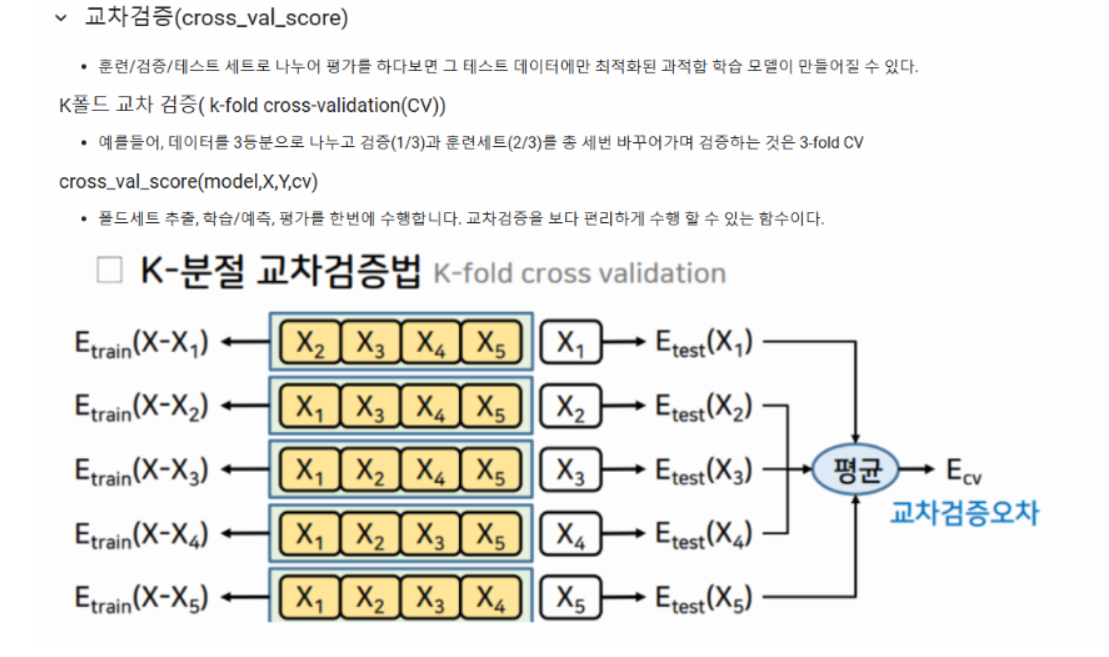</p>

In [71]:
boston = load_extended_boston()
X,y = boston
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression().fit(X_train, y_train)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
y_train_std = scaler.fit_transform(y_train.reshape(-1,1))
#교차 검증을 하기위해서 cross_val_score(모델,훈련X,훈련Y,cv=)
lr_cv_scores  = cross_val_score(lr,X_train_std,y_train_std,cv=5)

In [72]:
print(f"lr_cv_scores => {lr_cv_scores}")
print("K-Fold Cross Validation(교차 검증 오차)")
print(f"Mean CV Score =>{np.mean(lr_cv_scores)}")

lr_cv_scores => [0.80853717 0.64504394 0.63136345 0.81640945 0.90823456]
K-Fold Cross Validation(교차 검증 오차)
Mean CV Score =>0.7619177139392941


In [73]:
from sklearn.metrics import r2_score
def my_k_fold_cross_validation(model,X,y,k):
    fold_size = len(X) // k
    scores = []
    for i in range(k):
        X_val_fold = X[i * fold_size:(i + 1) * fold_size]
        y_val_fold = y[i * fold_size:(i + 1) * fold_size]
        print("X_val_fold : ",X_val_fold)
        X_train_fold = np.concatenate([X[:i * fold_size],X[(i+1) * fold_size:]],axis=0)
        y_train_fold = np.concatenate([y[:i * fold_size], y[(i + 1) * fold_size:]], axis=0)
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        score = r2_score(y_val_fold,y_pred)
        scores.append(score)
    return np.array(scores)

boston = load_extended_boston()
X,y = boston
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
lr = LinearRegression()
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
y_train_std = scaler.fit_transform(y_train.reshape(-1,1))
lr_cv_scores2 = my_k_fold_cross_validation(lr, X_train_std, y_train_std, 5)

X_val_fold :  [[-0.3906002   0.42637011 -0.74491444 ...  0.36421267  1.12348468
   0.53023343]
 [-0.40127639  0.5525335  -0.84901832 ...  0.51511027 -0.25724873
  -0.53727608]
 [-0.40110543  1.18335044 -0.66648002 ...  0.36652044 -0.76127424
  -0.71585689]
 ...
 [-0.40636774  0.34226119 -1.1057128  ...  0.13591448 -1.22925442
  -0.79706273]
 [-0.40870305  0.67869689  0.56422741 ...  0.47813065 -0.42621771
  -0.60765956]
 [-0.31646948 -0.49882807 -0.4197681  ... -1.31335479 -0.29445118
  -0.33167848]]
X_val_fold :  [[-0.34903641  0.34226119 -1.01444365 ...  0.34961337 -0.57933106
  -0.6590047 ]
 [-0.40923049  2.86552895 -1.36383336 ...  0.42347694 -0.66903453
  -0.69081541]
 [-0.12530077 -0.49882807  1.21166794 ... -2.63732777  0.34007709
   2.43708236]
 ...
 [-0.1171357  -0.49882807  1.21166794 ... -3.1810468  -0.92051709
   0.18561997]
 [-0.40713405 -0.49882807 -0.84046183 ...  0.51511027 -0.17668725
  -0.49882924]
 [ 0.70014043 -0.49882807  1.00060803 ...  0.51511027  1.97058593
   1

In [74]:
print(f"lr_cv_scores => {lr_cv_scores2}")
print("K-Fold Cross Validation(교차 검증 오차)")
print(f"Mean CV Score =>{np.mean(lr_cv_scores2)}")

lr_cv_scores => [0.79900168 0.68004441 0.62093026 0.80821643 0.91257606]
K-Fold Cross Validation(교차 검증 오차)
Mean CV Score =>0.7641537681672522


In [75]:
#사이킷 런으로 교차 검증 연습문제
df = pd.read_csv('dataset/Advertising.csv',index_col=0)
X = df[['FB', 'TV', 'Newspaper']].values
y = df['Sales'].values

In [76]:
#1----------------------------------------------
# 데이터를 훈련 세트와 테스트 세트로 분할 rd=42 , 0.3 분할 해보기 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)
print(y_train.shape,y_test.shape)
print(y_train.reshape(-1, 1).shape)
#2----------------------------------------------
# 표준화 적용
scaler_X  = StandardScaler()
X_train_std  = scaler_X.fit_transform(X_train)
X_test_std  = scaler_X.transform(X_test)
scaler_Y = StandardScaler()
#.flatten()은 fit_transform이나 transform 메서드가 기본적으로 2차원 배열을 반환하기 때문에 호출
#Y_train과 Y_test는 원래 1차원 배열이므로, 예측 후 결과를 원래의 1차원 형태로 복원하기 위해 사용
y_train_std = scaler_Y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_std = scaler_Y.transform(y_test.reshape(-1, 1)).flatten()
#3--------------------------------------
# LinearRegression 모델 생성 및 학습
model = LinearRegression()
model.fit(X_train_std,y_train_std)
#4----------------------------------------------
# 예측 및 평가  해보기 
y_pred = model.predict(X_test_std)
mse = mean_squared_error(y_test_std, y_pred)
score = model.score(X_test_std,y_test_std)
print("Linear Test MSE:", mse)
print("Test Score:",score)
# 교차 검증을 통한 모델 평가 cv = 5
print(f"k-fold 점수:{np.mean(cross_val_score(model,X_train_std,y_train_std,cv=5))}")
# 교차 검증을 통한 모델 평가 cv = 5
"""
Linear Test MSE: 0.144689547572668
Test Score: 0.8609466508230369
k-fold 점수:0.8831447829945454
"""

#5----------------------------------------------
# 예측 및 평가  해보기 
new_data = np.array([[230.1, 58.4, 46.8]])
new_data_std = scaler_X.transform(new_data)
pre_sales_std = model.predict(new_data_std)
# 표준화된 값으로 서비스 할 수 없으니 inverse_transform 사용해서 원래 값으로 돌려준다.
pre_sales = scaler_Y.inverse_transform(pre_sales_std.reshape(-1, 1))
print(f"예측된 Sales 값: {pre_sales[0][0]}")
#6---------------------------------------------
#################################################################
# 표준화를 적용한 리지 회귀 모델 생성 및 학습 
# 1) Ridge 생성한다. 적절한 alpha 부여한다. 1.0 , 학습을 시킨다.
"""
릿지 점수:[0.86450803 0.93774179 0.91609851 0.93076346 0.76661208]
릿지 점수:0.8831447734106108
Ridge MSE : 0.144689634162588
릿지 회귀를 적용한 예측된 판매량 : 24.807410215510306
"""

(140,) (60,)
(140, 1)
Linear Test MSE: 0.14468954757266791
Test Score: 0.8609466508230369
k-fold 점수:0.8831447829945456
예측된 Sales 값: 24.80747822372921


'\n릿지 점수:[0.86450803 0.93774179 0.91609851 0.93076346 0.76661208]\n릿지 점수:0.8831447734106108\nRidge MSE : 0.144689634162588\n릿지 회귀를 적용한 예측된 판매량 : 24.807410215510306\n'

In [77]:
#################################################################
# 표준화를 적용한 리지 회귀 모델 생성 및 학습 
# 1) Ridge 생성한다. 적절한 alpha 부여한다. 1.0 , 학습을 시킨다.
ridge_model = Ridge(alpha=0.001,max_iter=100000)
ridge_model.fit(X_train_std,y_train_std)
# 교차 검증을 통한 모델 평가 : cross_val_score(model,X_train,Y_train,cv=5)
ridge_score = cross_val_score(ridge_model,X_train_std,y_train_std,cv=5)
print(f"릿지 점수:{ridge_score}")
print(f"릿지 점수:{np.mean(ridge_score)}")
# 예측 
y_pred_ridge = ridge_model.predict(X_test_std)
mse_ridge = mean_squared_error(y_test_std,y_pred_ridge)
print(f"Ridge MSE : {mse_ridge}")
new_data = np.array([[230.1, 58.4, 46.8]])
new_data_std = scaler_X.transform(new_data)
prediect_sales_std = ridge_model.predict(new_data_std)
prediect_sales = scaler_Y.inverse_transform(prediect_sales_std.reshape(-1,1))
print(f"릿지 회귀를 적용한 예측된 판매량 : {prediect_sales[0][0]}")

릿지 점수:[0.86450803 0.93774179 0.91609851 0.93076346 0.76661208]
릿지 점수:0.8831447734106106
Ridge MSE : 0.14468963416258804
릿지 회귀를 적용한 예측된 판매량 : 24.807410215510302


<h2 id="statsmodels">statsmodels</h2><p>: R 에서 제공하는 통계적인 데이터를 파이썬에 쉽게 사용하기 위한 모듈</p>

<p>1.데이터 클리닝/준비: 누락된 값, 이상치 등을 처리하고 데이터를 분석에 적합한 형태로 변경</p>

<p>2.EDA(탐색적 데이터 분석): 데이터를 시각화하 해서 이해한다.
데이터 간의 관계나 패턴을 발견할 때 주로 사용함.</p>

<p>3.모델 구축: 통계적 또는 머신러닝 기법을 사용하여 모델을 구축하고,
주어진 온도에서 O-링이 열적 스트레스를 받을 확률을 예측</p>

In [80]:
#!pip install statsmodels

In [81]:
# 통계 모듈
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [82]:
# 예제1. 미국 우주 왕복선 폭파원인
# o형링의 손상(distress_ct)이  온도(temperature), 압력(field_check_pressure),
# 비행기번호(flight_num) 이 3가지중에 어떤게 더 영향이 큰지 ?

In [83]:
os.listdir('dataset')

['Advertising.csv',
 'auto-mpg.csv',
 'challenger.csv',
 'five.png',
 'linear.csv',
 'manhattan.csv',
 'rabbit.jpg']

In [84]:
df = pd.read_csv('dataset/challenger.csv')
df.head(2)

,distress_ct,temperature,field_check_pressure,flight_num
0,0,66,50,1
1,1,70,50,2


In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   distress_ct           23 non-null     int64
 1   temperature           23 non-null     int64
 2   field_check_pressure  23 non-null     int64
 3   flight_num            23 non-null     int64
dtypes: int64(4)
memory usage: 868.0 bytes


In [86]:
df.isnull().sum()

distress_ct             0
temperature             0
field_check_pressure    0
flight_num              0
dtype: int64

In [87]:
df.columns

Index(['distress_ct', 'temperature', 'field_check_pressure', 'flight_num'], dtype='str')

In [88]:
# 미국 우주 왕복선 폭파원인
# o형링[distress_ct]의 손상이 온도, 압력, 비행기번호 이 3가지중에 어떤게 더 영향이 큰지 ?
# 1. dataFrame을 가지고 사용
# smf.ols(formula='y ~ x1 + x2 + xn',data=DF)
model = smf.ols(formula='distress_ct ~ temperature + field_check_pressure + flight_num',data=df)
result = model.fit()
print(result.summary())
#y = 3.5271 -0.0514 * x1 +  0.0018 * x2 + 0.0143 * x3 : 다중회귀 식

                            OLS Regression Results                            
Dep. Variable:            distress_ct   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                     3.563
Date:                Thu, 20 Aug 2026   Prob (F-statistic):             0.0337
Time:                        22:35:27   Log-Likelihood:                -17.308
No. Observations:                  23   AIC:                             42.62
Df Residuals:                      19   BIC:                             47.16
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.5271 

In [89]:
result

In [90]:
# 연습문제
# statsmodels 패키지를 이용해서 방금 다중회귀 분석을 해보았는데
# 이번에는 중요한 독립변수인 temperature 만 이용해서 단순회귀 분석을 진행하고 
# 분석된 결과를 출력하세요 ~~
# 종속변수 : distress_ct ( o 형링 파손수 )
# 독립변수 : temperature (온도)
#model = LinearRegression().fit(df['temperature'].values,df['distress_ct'].values)
model = smf.ols(formula="distress_ct ~ temperature",data=df)
result = model.fit()
print(result.summary())

                            OLS Regression Results                            
Dep. Variable:            distress_ct   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     7.426
Date:                Thu, 20 Aug 2026   Prob (F-statistic):             0.0127
Time:                        22:35:33   Log-Likelihood:                -18.959
No. Observations:                  23   AIC:                             41.92
Df Residuals:                      21   BIC:                             44.19
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.6984      1.220      3.033      

In [91]:
# y =  ax + b
# Intercept       3.6984 절푠
# temperature    -0.0475 기울기
y = 3.6984 -0.0475  * 70
y

0.37339999999999973

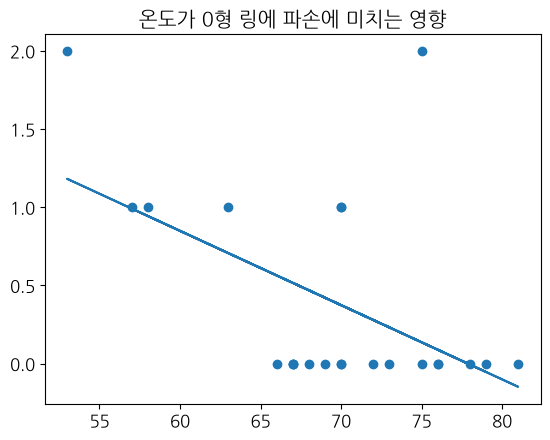

In [92]:
plt.scatter(df['temperature'],df['distress_ct'])
y = 3.6984 -0.0475 * df['temperature']
plt.plot(df['temperature'],y)
plt.title('온도가 0형 링에 파손에 미치는 영향')
plt.show()

In [93]:
# 학습된 모델의 주소 -> 통계 모듈에서 봤던 속성을 접근 
result

In [94]:
# 기울기(coef), 절편(Intercept)이 모두 들어가 있다.
result.params  , type(result.params)

(Intercept      3.698413
 temperature   -0.047540
 dtype: float64,
 pandas.Series)

In [95]:
# 기울기와 절편을 각각 꺼내서 대입
w = result.params['temperature']
w

np.float64(-0.04753968253968249)

In [96]:
#Series는 자연인덱스도 가지고 있기 때문에 인덱스로도 접근할 수 있다.
w = result.params.iloc[1]
w

np.float64(-0.04753968253968249)

In [97]:
# 절편 
b = result.params['Intercept']
b

np.float64(3.698412698412695)

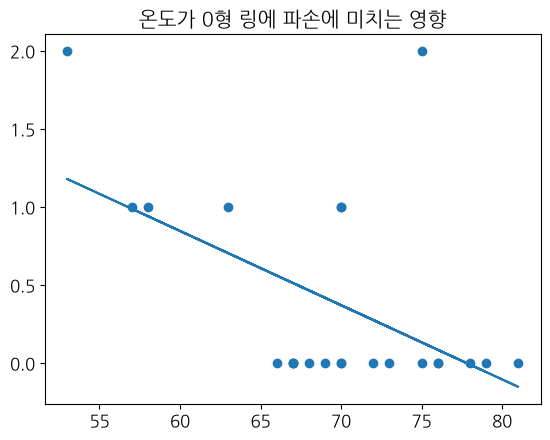

In [98]:
plt.scatter(df['temperature'],df['distress_ct'])
#y = 3.6984  - 0.0475 * df['temperature']
#y = wx + b
y = w * df['temperature'] + b
plt.plot(df['temperature'],y)
plt.title('온도가 0형 링에 파손에 미치는 영향')
plt.show()

<h2 id="EDA-(Exploratory-Data-Analysis)-%ED%83%90%EC%83%89%EC%A0%81-%EB%8D%B0%EC%9D%B4%ED%84%B0-%EB%B6%84%EC%84%9D">EDA (Exploratory Data Analysis) 탐색적 데이터 분석¶</h2>
개별 데이터 관찰
통계 값 활용
시각화 활용
머신러닝 기법 활용
이상치 시각화 등

In [99]:
#Pandas에서 상관관계를 출력 1:양, -1:음
corrv = df.corr()
corrv

,distress_ct,temperature,field_check_pressure,flight_num
distress_ct,1.000000,-0.511126,0.284666,0.173578
temperature,-0.511126,1.000000,0.039818,0.230770
field_check_pressure,0.284666,0.039818,1.000000,0.839932
flight_num,0.173578,0.230770,0.839932,1.000000


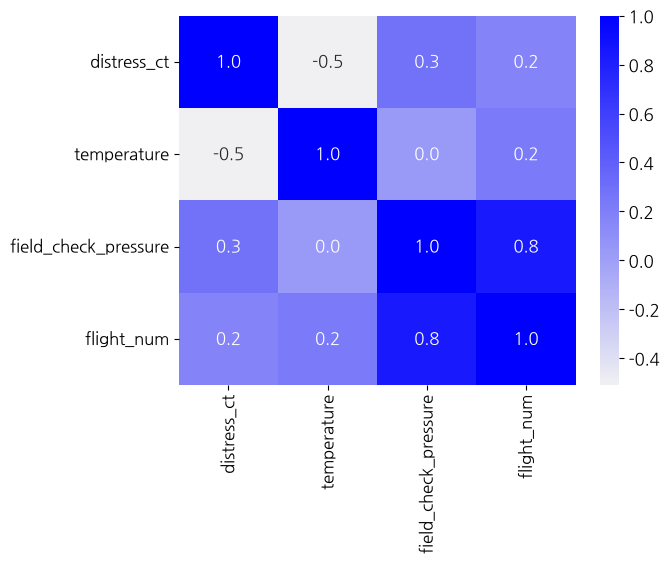

In [100]:
# annot=True : 상관계수를 출력
# seaboran에서 지원하는 색상 지원 옵션 : cmap
mycmap = sns.light_palette('blue',as_cmap=True)
# 소수점 전체 3자리로 , 소수점 이하가 한 자리까지만 표시
sns.heatmap(corrv,annot=True,cmap=mycmap,fmt='3.1f')
plt.show()

In [101]:
df.columns

Index(['distress_ct', 'temperature', 'field_check_pressure', 'flight_num'], dtype='str')

In [102]:
corrv = df.corr()
corrv.columns

Index(['distress_ct', 'temperature', 'field_check_pressure', 'flight_num'], dtype='str')

In [103]:
#Pandas 문법 
#corrv.loc[행,열]를 사용해서 특정 상관계수만을 뽑아 오기 
corrv

,distress_ct,temperature,field_check_pressure,flight_num
distress_ct,1.000000,-0.511126,0.284666,0.173578
temperature,-0.511126,1.000000,0.039818,0.230770
field_check_pressure,0.284666,0.039818,1.000000,0.839932
flight_num,0.173578,0.230770,0.839932,1.000000


In [104]:
corrv.loc['temperature':,'distress_ct'] 
corrv.loc['temperature':,'distress_ct'].abs()

temperature             0.511126
field_check_pressure    0.284666
flight_num              0.173578
Name: distress_ct, dtype: float64

In [105]:
corrv.loc['temperature':,'distress_ct'].abs().sort_values(ascending=False)

temperature             0.511126
field_check_pressure    0.284666
flight_num              0.173578
Name: distress_ct, dtype: float64

In [106]:
#상관관계가 높은 순으로 정렬 
cv = corrv.loc['temperature':,'distress_ct'].abs().sort_values(ascending=False)
df_corv = pd.DataFrame(cv)
df_corv.style.background_gradient(cmap=mycmap)

,distress_ct
temperature,0.511126
field_check_pressure,0.284666
flight_num,0.173578


In [107]:
df_corv.style.background_gradient(cmap='Reds')

,distress_ct
temperature,0.511126
field_check_pressure,0.284666
flight_num,0.173578


In [109]:
# 연습문제)
# manhattan 값을 사용해서 특징 추출하기 (상관관계가 높은 수)
# 1) 상관관계를 확인 - 추릴건 추리고...
# 2) smf.ols 사용해서 summar() 확인
# 2 -1) 회귀계수
# 2 -2) 기울기, 절편 *****
# 3) 제일 높은 독립 변수 하나를 단순 선형회귀로 산점도 찍어서 시각화 이후 실행
comm = """
rental_id rental ID
rent  임대료 ($) 주택 임대료 (Y)
bedrooms  침실수
bathrooms 화장실수
size_sqft 평수(feet)
min_to_subway 지하철과의 거리 (minutes)
floor 층수
building_age_yrs  건물 연령
no_fee  중계수수료 (0 for fee, 1 for no fee)
has_roofdeck  옥상 (o for no, 1 for yes)
has_washer_dryer  세탁기/건조기 (0/1)
has_doorman 도어맨 (0/1)
has_elevator  엘리베이터 (0/1)
has_dishwasher  식기세척기 (0/1)
has_patio 안마당(patio) (0/1)
has_gym 헬스장(gym) (0/1)
neighborhood  이웃 (ex: 한인타운)
#submarket  submarket (ex: North Brooklyn)
borough	borough (ex: Brooklyn)
"""

<p>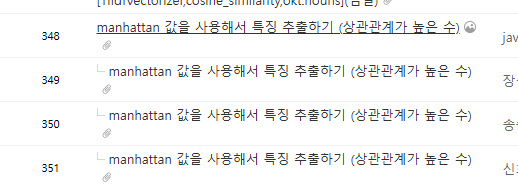</p>

In [110]:
#1.  manhattan.csv 를 DataFrame으로 불러 오기
os.listdir('dataset')

['Advertising.csv',
 'auto-mpg.csv',
 'challenger.csv',
 'five.png',
 'linear.csv',
 'manhattan.csv',
 'rabbit.jpg']

In [111]:
# 1. CSV 파일을 DataFrame으로 불러오기
df = pd.read_csv('dataset/manhattan.csv')
df.head(2)

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym,neighborhood,borough
0,1545,2550,0.0,1,480,9,2.0,17,1,1,0,0,1,1,0,1,Upper East Side,Manhattan
1,2472,11500,2.0,2,2000,4,1.0,96,0,0,0,0,0,0,0,0,Greenwich Village,Manhattan


In [112]:
# 2. 컬럼 확인 (컬럼명과 개수)
df.columns , len(df.columns)

(Index(['rental_id', 'rent', 'bedrooms', 'bathrooms', 'size_sqft',
        'min_to_subway', 'floor', 'building_age_yrs', 'no_fee', 'has_roofdeck',
        'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher',
        'has_patio', 'has_gym', 'neighborhood', 'borough'],
       dtype='str'),
 18)

In [113]:
# 3. 기본 정보 확인 (데이터 타입, 결측치, 요약정보 등)
df.info()
# 결측치 확인
# df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3539 entries, 0 to 3538
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rental_id         3539 non-null   int64  
 1   rent              3539 non-null   int64  
 2   bedrooms          3539 non-null   float64
 3   bathrooms         3539 non-null   int64  
 4   size_sqft         3539 non-null   int64  
 5   min_to_subway     3539 non-null   int64  
 6   floor             3539 non-null   float64
 7   building_age_yrs  3539 non-null   int64  
 8   no_fee            3539 non-null   int64  
 9   has_roofdeck      3539 non-null   int64  
 10  has_washer_dryer  3539 non-null   int64  
 11  has_doorman       3539 non-null   int64  
 12  has_elevator      3539 non-null   int64  
 13  has_dishwasher    3539 non-null   int64  
 14  has_patio         3539 non-null   int64  
 15  has_gym           3539 non-null   int64  
 16  neighborhood      3539 non-null   str    
 17  boroug

In [114]:
df['neighborhood'].value_counts()[:3]   # 상위 3개 지역

neighborhood
Upper West Side    579
Upper East Side    500
Midtown East       460
Name: count, dtype: int64

In [115]:
df['bathrooms'].value_counts()

bathrooms
1    2420
2     930
3     165
4      13
0       9
5       2
Name: count, dtype: int64

In [116]:
df['borough'].value_counts()

borough
Manhattan    3539
Name: count, dtype: int64

In [117]:
del df['borough']

In [118]:
len(df.columns)

17

In [119]:
df.describe()

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym
count,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000,3539.000000
mean,5332.589997,5138.940379,1.351936,1.366770,939.727324,4.970896,11.908307,51.994914,0.403504,0.154846,0.160215,0.281153,0.294716,0.185646,0.055100,0.174908
std,3311.552136,3162.824760,0.967595,0.599588,477.949074,5.513589,10.960893,39.380433,0.490669,0.361809,0.366857,0.449625,0.455979,0.388875,0.228208,0.379942
min,1.000000,1300.000000,0.000000,0.000000,250.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2443.500000,3150.000000,1.000000,1.000000,613.000000,2.000000,4.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5128.000000,4000.000000,1.000000,1.000000,800.000000,4.000000,8.000000,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8149.500000,6000.000000,2.000000,2.000000,1141.000000,6.000000,17.000000,90.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,11349.000000,20000.000000,5.000000,5.000000,4800.000000,43.000000,83.000000,180.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [120]:
# 4. 상관계수 확인
# 문자열 컬럼(neighborhood)은 제외해야 함
df.columns[:-1] , len(df.columns[:-1] )

(Index(['rental_id', 'rent', 'bedrooms', 'bathrooms', 'size_sqft',
        'min_to_subway', 'floor', 'building_age_yrs', 'no_fee', 'has_roofdeck',
        'has_washer_dryer', 'has_doorman', 'has_elevator', 'has_dishwasher',
        'has_patio', 'has_gym'],
       dtype='str'),
 16)

In [121]:
df2 = df[df.columns[:-1]]
df2.tail(2)

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym
3537,5188,3475,1.0,1,651,6,5.0,14,1,0,1,1,1,1,0,1
3538,4718,4500,1.0,1,816,4,11.0,9,0,1,1,1,1,0,1,1


In [122]:
corrv = df2.corr()
corrv

,rental_id,rent,bedrooms,bathrooms,size_sqft,min_to_subway,floor,building_age_yrs,no_fee,has_roofdeck,has_washer_dryer,has_doorman,has_elevator,has_dishwasher,has_patio,has_gym
rental_id,1.000000,-0.134347,-0.070290,-0.109414,-0.107711,0.009615,-0.082586,0.028543,0.064919,-0.023335,-0.072738,-0.057786,-0.060152,-0.029615,-0.004253,-0.023457
rent,-0.134347,1.000000,0.638336,0.769474,0.857954,0.035164,0.215867,-0.128895,-0.101497,0.035165,0.053873,0.031302,0.051860,0.052241,0.029302,0.040609
bedrooms,-0.070290,0.638336,1.000000,0.720885,0.771263,0.076543,0.043539,0.037228,-0.100352,0.002938,0.008721,-0.017331,-0.006771,0.005467,0.003037,-0.004112
bathrooms,-0.109414,0.769474,0.720885,1.000000,0.803627,0.086932,0.127969,-0.095421,-0.062205,0.019556,0.025752,0.014745,0.021150,0.038829,0.042304,0.029739
size_sqft,-0.107711,0.857954,0.771263,0.803627,1.000000,0.039448,0.107186,0.014489,-0.141451,0.024822,0.038263,0.026098,0.040916,0.050364,0.021921,0.029347
min_to_subway,0.009615,0.035164,0.076543,0.086932,0.039448,1.000000,0.082445,-0.184682,0.080088,-0.020693,-0.001327,-0.009012,-0.000410,-0.012244,0.001500,-0.004315
floor,-0.082586,0.215867,0.043539,0.127969,0.107186,0.082445,1.000000,-0.389260,0.104317,0.056322,0.038870,0.095963,0.068917,0.002337,0.059423,0.065410
building_age_yrs,0.028543,-0.128895,0.037228,-0.095421,0.014489,-0.184682,-0.389260,1.000000,-0.221429,-0.041305,-0.030014,-0.047265,-0.060627,-0.027420,-0.050321,-0.063110
no_fee,0.064919,-0.101497,-0.100352,-0.062205,-0.141451,0.080088,0.104317,-0.221429,1.000000,-0.095718,-0.070324,-0.182547,-0.161519,-0.078660,-0.049684,-0.101230
has_roofdeck,-0.023335,0.035165,0.002938,0.019556,0.024822,-0.020693,0.056322,-0.041305,-0.095718,1.000000,0.313459,0.489836,0.516534,0.331999,0.122568,0.561626


In [123]:
cv = corrv.loc['bedrooms':,'rent'].abs().sort_values(ascending=False)
df_corv = pd.DataFrame(cv)
df_corv.style.background_gradient(cmap='Reds')

,rent
size_sqft,0.857954
bathrooms,0.769474
bedrooms,0.638336
floor,0.215867
building_age_yrs,0.128895
no_fee,0.101497
has_washer_dryer,0.053873
has_dishwasher,0.052241
has_elevator,0.051860
has_gym,0.040609


In [124]:
model = smf.ols(formula='rent ~ size_sqft + bathrooms + bedrooms + floor', data=df)
result = model.fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rent   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.772
Method:                 Least Squares   F-statistic:                     2988.
Date:                Thu, 20 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:37:53   Log-Likelihood:                -30928.
No. Observations:                3539   AIC:                         6.187e+04
Df Residuals:                    3534   BIC:                         6.190e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1082.5571     67.685    -15.994      0.000   -1215.263    -949.852
size_sqft      4.8537      0.101     48.032      0.000       4.656       5.052
bathrooms   1284.6414     74.208     17.311      0.000    1139.146    1430.137
bedrooms    -352.1846     42.969     -8.196      0.000    -436.432    -267.937
floor         31.9650      2.346     13.624      0.000      27.365      36.565
==============================================================================
Omnibus:                      970.112   Durbin-Watson:                   2.061
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10212.357
Skew:                           0.995   Prob(JB):                         0.00
Kurtosis:                      11.080   Cond. No.                     3.60e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.6e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [125]:
# 단일 변수(size_sqft)만 포함한 모델
model1 = smf.ols(formula='rent ~ size_sqft', data=df)
result1 = model1.fit()
result1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   rent   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     9865.
Date:                Thu, 20 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:37:57   Log-Likelihood:                -31186.
No. Observations:                3539   AIC:                         6.238e+04
Df Residuals:                    3537   BIC:                         6.239e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -196.3639     60.264     -3.258      0.001    -314.519     -78.209
size_sqft      5.6775      0.057     99.323      0.000       5.565       5.790
==============================================================================
Omnibus:                      753.632   Durbin-Watson:                   2.020
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10468.420
Skew:                           0.614   Prob(JB):                         0.00
Kurtosis:                      11.336   Cond. No.                     2.33e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.33e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

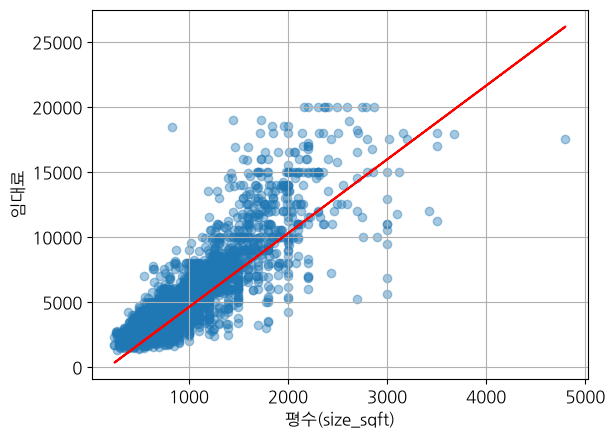

In [126]:
X = df[['size_sqft']]
plt.scatter(X,df[['rent']],alpha=0.4)
# y = w*x + b (회귀직선)
y = result1.params['size_sqft'] * X + result.params['Intercept']
plt.plot(X,y,'r')
plt.grid(True)
plt.xlabel('평수(size_sqft)')
plt.ylabel('임대료')
plt.show()

In [127]:
model = smf.ols(formula='rent  ~ size_sqft + bedrooms + bathrooms  + min_to_subway  + \
building_age_yrs + floor + has_elevator',data=df)
result = model.fit()
print(result.summary())
print('*'*30)
print(result.params)
print('Rsquaured : ', result.rsquared) 
print('Pvalue :', result.pvalues)

                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.779
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     1773.
Date:                Thu, 20 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:38:06   Log-Likelihood:                -30875.
No. Observations:                3539   AIC:                         6.177e+04
Df Residuals:                    3531   BIC:                         6.182e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         -508.3320     89.049  

In [128]:
# 7. 선형 회귀분석 학습 (train/test split)
X = df[['size_sqft','bedrooms', 'bathrooms','min_to_subway', 'floor','has_elevator']]
y = df[['rent']]
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=12)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

mlr = LinearRegression()
mlr.fit(X_train,y_train)
print(mlr.score(X_train,y_train))
print(mlr.score(X_test,y_test))

(2831, 6) (708, 6) (2831, 1) (708, 1)
0.7731478120791564
0.7673611895368103


In [129]:
new_data = [[2000,2,2,4,1,0]]
y_pred = mlr.predict(new_data)
y_pred

print(f"실제 가격 : {df[1:2]['rent'][1]} , 예측 가격 : {y_pred}")

실제 가격 : 11500 , 예측 가격 : [[10556.10636158]]
